In [1]:
import torch
import pandas as pd
import numpy as np
import tqdm
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    average_precision_score,
)

RANDOM_STATE = 42

In [2]:
model = torch.hub.load('harritaylor/torchvggish', 'vggish')
model.eval()

Using cache found in /home/dk/.cache/torch/hub/harritaylor_torchvggish_master


VGGish(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

In [3]:
df = pd.read_csv('dataset.csv', sep=';')
df

,filename,duration,samplerate,tags,target
0,good/00f3da84-570e-40f5-9949-31cd811ff6ca.wav,12.415625,16000,чстрлшщ,1
1,good/01062fc6-fbb8-4544-a0f5-2830899a91d0.wav,6.480000,16000,чстр,1
2,good/01611791-7a64-42c6-82f4-1f8d46603999.wav,11.940000,16000,лш,1
3,good/0165e884-ccbe-4a43-b2e8-fa64952dc825.wav,3.436187,16000,рлш,1
4,good/018e28b3-b8de-4023-b2d8-39c6455c6f33.wav,5.280000,16000,стрлш,1
...,...,...,...,...,...
2771,bad/ff366031-a519-49e4-a34e-156be75f128d.wav,18.680000,16000,стлш,0
2772,bad/ff7b8da9-595b-4ee6-bd15-7016f543ec34.wav,6.501188,16000,стрлш,0
2773,bad/ffb3b065-80b4-44b2-bd89-f67e138e41d2.wav,6.760000,16000,рл,0
2774,bad/ffcc0732-1dd2-41d9-bf5d-0bbdb8f48dd0.wav,8.540000,16000,стрл,0


Получим эмбеддинги аудиозаписей с помощью VGGish и классифицируем их с момощью методов классического ML. VGGish создает 128-размерные эмбеддинги для каждого 0.96 секундного фрейма аудиофайла, будем рассматривать каждый фрейм как отдельное наблюдение. В дальнейшем будут опробованы другие способы, так как очевидно, что не в каждом 0.96 секундном фрейме будут признаки дефектной речи, к тому же сегменты одного файла связаны и должны обрабатываться как одно наблюдение. Также 128-мерной размерности эмбеддинга маловато, эта модель выбрана только в качестве бейзлайна.

In [4]:
embeddings = np.empty((0, 129), int)
for row in tqdm.tqdm(df.itertuples(index=True), total=df.shape[0]):
    emb = model.forward(row.filename).cpu().detach().numpy()
    if emb.ndim == 1:
        emb = emb.reshape(1, -1)
    new_col = np.full((emb.shape[0], 1), row.target) 
    result = np.concatenate((emb, new_col), axis=1)
    embeddings = np.append(embeddings, result, axis=0)

  0%|          | 0/2776 [00:00<?, ?it/s]

100%|██████████| 2776/2776 [06:30<00:00,  7.11it/s]


In [5]:
pd.DataFrame(embeddings)

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,128
0,156.0,3.0,140.0,95.0,187.0,52.0,48.0,97.0,159.0,204.0,...,135.0,255.0,0.0,0.0,0.0,209.0,31.0,255.0,255.0,1.0
1,158.0,0.0,164.0,119.0,172.0,94.0,89.0,87.0,163.0,120.0,...,121.0,64.0,166.0,96.0,0.0,0.0,215.0,216.0,255.0,1.0
2,157.0,0.0,161.0,125.0,151.0,77.0,75.0,55.0,142.0,139.0,...,255.0,147.0,0.0,16.0,0.0,0.0,124.0,255.0,255.0,1.0
3,162.0,0.0,170.0,114.0,142.0,87.0,55.0,60.0,170.0,94.0,...,156.0,43.0,145.0,121.0,19.0,8.0,220.0,97.0,255.0,1.0
4,160.0,0.0,169.0,100.0,171.0,100.0,22.0,78.0,182.0,95.0,...,152.0,63.0,0.0,35.0,0.0,255.0,87.0,0.0,255.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28520,161.0,0.0,174.0,120.0,161.0,92.0,85.0,93.0,165.0,111.0,...,146.0,73.0,223.0,119.0,143.0,32.0,88.0,90.0,255.0,0.0
28521,157.0,5.0,162.0,122.0,166.0,65.0,92.0,64.0,182.0,167.0,...,163.0,37.0,150.0,44.0,0.0,145.0,177.0,255.0,255.0,0.0
28522,160.0,0.0,171.0,104.0,174.0,98.0,64.0,63.0,184.0,100.0,...,187.0,103.0,215.0,94.0,61.0,7.0,177.0,64.0,255.0,0.0
28523,168.0,7.0,173.0,125.0,156.0,83.0,105.0,61.0,202.0,122.0,...,138.0,23.0,255.0,80.0,235.0,100.0,255.0,255.0,255.0,0.0


In [6]:
X = embeddings[:, :-1]
y = embeddings[:, -1]

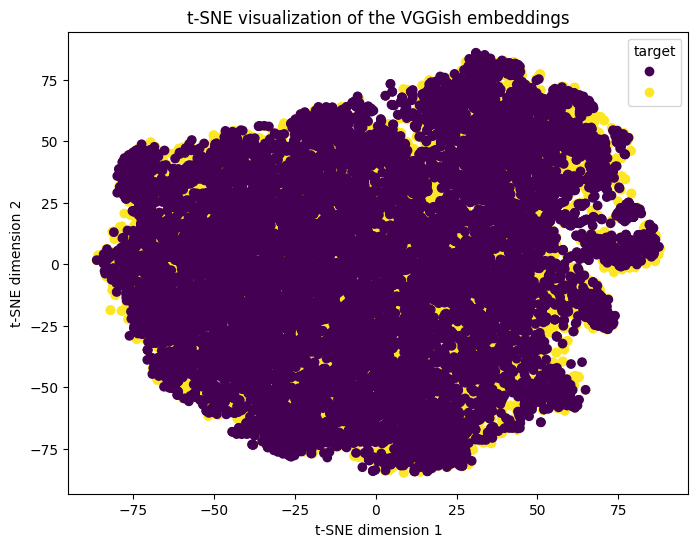

In [7]:
tsne = TSNE(random_state=RANDOM_STATE)
tsne_result = tsne.fit_transform(X)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=y)
plt.legend(handles=scatter.legend_elements()[0], title="target")
plt.title('t-SNE visualization of the VGGish embeddings')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.show()

t-SNE не смог выделить кластеры.

Попробуем применить логистическую регрессию и метод опорных векторов для классификации

In [8]:
def evaluate_clf_model(model, X, y, caption = '', n_splits = 5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    acc_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    balanced_acc_scores = []
    auc_scores = []
    ap_scores = []
    for (train_idx, val_idx) in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc_scores.append(accuracy_score(y_val, y_pred))
        precision_scores.append(precision_score(y_val, y_pred))
        recall_scores.append(recall_score(y_val, y_pred))
        f1_scores.append(f1_score(y_val, y_pred))
        balanced_acc_scores.append(balanced_accuracy_score(y_val, y_pred))

        y_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_proba))
        ap_scores.append(average_precision_score(y_val, y_proba))

    result = {
        "Model": caption,
        "Accuracy": np.mean(acc_scores),
        "Balanced accuracy": np.mean(balanced_acc_scores),
        "F1": np.mean(f1_scores),
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),        
        "ROC-AUC": np.mean(auc_scores),
        "Average precision (PR-AUC)": np.mean(ap_scores),
    }
    return result

In [9]:
metrics = []
clf_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(random_state=RANDOM_STATE))
])
metrics.append(evaluate_clf_model(clf_logreg, X, y, "LogReg"))

pd.DataFrame(metrics)

,Model,Accuracy,Balanced accuracy,F1,Precision,Recall,ROC-AUC,Average precision (PR-AUC)
0,LogReg,0.630429,0.6048,0.707103,0.64941,0.776056,0.666184,0.717795


In [10]:
clf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
])
metrics.append(evaluate_clf_model(clf_svm, X, y, "SVM"))

pd.DataFrame(metrics)

,Model,Accuracy,Balanced accuracy,F1,Precision,Recall,ROC-AUC,Average precision (PR-AUC)
0,LogReg,0.630429,0.604800,0.707103,0.649410,0.776056,0.666184,0.717795
1,SVM,0.662857,0.635507,0.736154,0.669046,0.818259,0.709024,0.753428


Видим, что SVM показал себя чуть лучше. Выбираем это решение в качестве бейзлайна.

Для дальнейших исследований нужно попробовать другие методы получения эмбеддингов, а также другие методы классификации.